In [1]:
import sys
sys.path.append('../')

import torch
import pandas as pd
import optuna
import warnings
from copy import deepcopy
from torch.utils.data import DataLoader
from src.mypackage.data_preparation import prepare_statistical_data
from src.mypackage.torch_dataset import EnergyDataset
from src.mypackage.trainer import Trainer
from src.mypackage.rnn_models import RNNModel
from src.mypackage.forecasting import dnn_forecast
from src.mypackage.evaluation import print_metrics, get_true_values
from src.mypackage.visualization import plot_forecast
from src.mypackage.utils import set_seed, SEED

warnings.filterwarnings("ignore")
set_seed(SEED)

In [2]:
# ========== データ読み込みとデータセット準備 ==========
df = pd.read_csv("../data/raw/PJME_hourly.csv")
_, tmp = prepare_statistical_data(df)
timesteps = tmp["Datetime"].copy()
del tmp
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

SEQ_LEN = 168
PRED_LEN = 24
SHIFT = 24
BATCH_SIZE = 32

# ========== データセット作成 ==========
dataset = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=PRED_LEN, mode="re-train")
retrain_dataset = deepcopy(dataset)
train_dataset = deepcopy(dataset)
train_dataset.mode_switch("train")
valid_dataset = deepcopy(dataset)
valid_dataset.mode_switch("val")
test_dataset = deepcopy(dataset)
test_dataset.mode_switch("test")

# DataLoader作成
retrain_loader = DataLoader(retrain_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Whole dataset size: {len(retrain_dataset)}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Input features: {train_dataset[0][0].shape[1]}")


Dataset shape: (145366, 2)
Columns: ['Datetime', 'PJME_MW']
Whole dataset size: 5654
Train dataset size: 5289
Val dataset size: 365
Test dataset size: 365
Input features: 19


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ========== ハイパーパラメータ設定 ==========
# 固定
NUM_EPOCHS = 100
INPUT_SIZE = train_dataset[0][0].shape[1]
EARLY_STOPPING_PATIENCE = 10
OUTPUT_SIZE = PRED_LEN

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    hidden_size = 2 ** trial.suggest_int("hidden_size", 4, 9)
    num_layers = trial.suggest_int("num_layers", 1, 4)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    model_type = trial.suggest_categorical("model_type", ["RNN", "LSTM", "GRU"])

    model = RNNModel(input_size=INPUT_SIZE, 
                     hidden_size=hidden_size, 
                     num_layers=num_layers, 
                     output_size=OUTPUT_SIZE, 
                     dropout=dropout,
                     rnn_type=model_type).to(device)

    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        checkpoint_dir="../models/rnn_checkpoints"
    )
    history = trainer.train(num_epochs=NUM_EPOCHS, verbose=0)
    best_iteration = trainer.early_stopping.best_iteration
    trial.set_user_attr("best_iteration", best_iteration)
    return min(history['val_loss'])

Using device: cuda


In [4]:
# パラメータ探索の実行
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=50)
print(study.best_params)

[I 2026-07-19 08:19:16,930] A new study created in memory with name: no-name-dbbdfd51-316b-4409-ac67-87a73ad410b2
[I 2026-07-19 08:21:43,541] Trial 0 finished with value: 0.09212768605599801 and parameters: {'learning_rate': 0.0001329291894316216, 'weight_decay': 0.0007114476009343421, 'hidden_size': 8, 'num_layers': 3, 'dropout': 0.1624074561769746, 'model_type': 'GRU'}. Best is trial 0 with value: 0.09212768605599801.


Checkpoint loaded from ../models/rnn_checkpoints/best_model.pt


[I 2026-07-19 08:22:24,507] Trial 1 finished with value: 0.11556512024253607 and parameters: {'learning_rate': 0.0006358358856676254, 'weight_decay': 0.000133112160807369, 'hidden_size': 4, 'num_layers': 4, 'dropout': 0.4329770563201687, 'model_type': 'RNN'}. Best is trial 0 with value: 0.09212768605599801.


Checkpoint loaded from ../models/rnn_checkpoints/best_model.pt


[I 2026-07-19 08:22:59,677] Trial 2 finished with value: 0.09349820359299581 and parameters: {'learning_rate': 8.17949947521167e-05, 'weight_decay': 3.752055855124284e-05, 'hidden_size': 6, 'num_layers': 2, 'dropout': 0.34474115788895177, 'model_type': 'GRU'}. Best is trial 0 with value: 0.09212768605599801.


...

Checkpoint loaded from ../models/rnn_checkpoints/best_model.pt


[I 2026-07-19 09:15:57,732] Trial 48 finished with value: 0.08998238450537126 and parameters: {'learning_rate': 0.00012206718699055329, 'weight_decay': 0.0001223659021223719, 'hidden_size': 6, 'num_layers': 1, 'dropout': 0.32791971947536575, 'model_type': 'GRU'}. Best is trial 27 with value: 0.0811353165966769.


Checkpoint loaded from ../models/rnn_checkpoints/best_model.pt


[I 2026-07-19 09:16:32,594] Trial 49 finished with value: 0.08206359638522069 and parameters: {'learning_rate': 0.000282387117966017, 'weight_decay': 3.5269966624075603e-06, 'hidden_size': 7, 'num_layers': 2, 'dropout': 0.4268340536980847, 'model_type': 'LSTM'}. Best is trial 27 with value: 0.0811353165966769.


Checkpoint loaded from ../models/rnn_checkpoints/best_model.pt
{'learning_rate': 0.0037327254957492603, 'weight_decay': 1.9894979547797e-06, 'hidden_size': 7, 'num_layers': 1, 'dropout': 0.35337975685605294, 'model_type': 'GRU'}


In [5]:
# モデルの再学習（1日予測）
model = RNNModel(input_size=INPUT_SIZE,
                 hidden_size=2**study.best_params["hidden_size"], 
                 num_layers=study.best_params["num_layers"], 
                 output_size=OUTPUT_SIZE, 
                 dropout=study.best_params["dropout"],
                 rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=retrain_loader,
                  test_loader=test_loader,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [1/10] - Train Loss: 0.181883, Val Loss: nan - Train MAE: 0.323271, Val MAE: nan
Epoch [2/10] - Train Loss: 0.132213, Val Loss: nan - Train MAE: 0.277978, Val MAE: nan
Epoch [3/10] - Train Loss: 0.120897, Val Loss: nan - Train MAE: 0.264855, Val MAE: nan
Epoch [4/10] - Train Loss: 0.112430, Val Loss: nan - Train MAE: 0.254152, Val MAE: nan
Epoch [5/10] - Train Loss: 0.107187, Val Loss: nan - Train MAE: 0.248028, Val MAE: nan
Epoch [6/10] - Train Loss: 0.103756, Val Loss: nan - Train MAE: 0.244546, Val MAE: nan
Epoch [7/10] - Train Loss: 0.100755, Val Loss: nan - Train MAE: 0.239654, Val MAE: nan
Epoch [8/10] - Train Loss: 0.101068, Val Loss: nan - Train MAE: 0.240132, Val MAE: nan
Epoch [9/10] - Train Loss: 0.098218, Val Loss: nan - Train MAE: 0.238023, Val MAE: nan
Epoch [10/10] - Train Loss: 0.099967, Val Loss: nan - Train MAE: 0.240946, Val MAE: nan
No best model checkpoint found; saved final model to ../models/rnn_checkpoints/final_model.pt


In [6]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/rnn_checkpoints/day_best_model.pth")
trainer.save_config("../models/rnn_checkpoints/day_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.111216
  Test MAE: 0.232044
  Test RMSE: 0.322348
Checkpoint saved to ../models/rnn_checkpoints/day_best_model.pth
Configuration saved to ../models/rnn_checkpoints/day_best_model_config.json


In [7]:
# 1週間予測用のデータセット
dataset_week = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=7*PRED_LEN, mode="re-train")
test_dataset_week = deepcopy(dataset_week)
test_dataset_week.mode_switch("test")

train_loader_week = DataLoader(dataset_week, batch_size=BATCH_SIZE, shuffle=True)
test_loader_week = DataLoader(test_dataset_week, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
# モデルの再学習（1週間予測）
model = RNNModel(input_size=INPUT_SIZE,
                 hidden_size=2**study.best_params["hidden_size"], 
                 num_layers=study.best_params["num_layers"], 
                 output_size=7*PRED_LEN,  # 1週間予測のため出力サイズを変更
                 dropout=study.best_params["dropout"],
                 rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_week,
                  test_loader=test_loader_week,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [1/10] - Train Loss: 0.325122, Val Loss: nan - Train MAE: 0.432014, Val MAE: nan
Epoch [2/10] - Train Loss: 0.256256, Val Loss: nan - Train MAE: 0.383092, Val MAE: nan
Epoch [3/10] - Train Loss: 0.240159, Val Loss: nan - Train MAE: 0.368095, Val MAE: nan
Epoch [4/10] - Train Loss: 0.231901, Val Loss: nan - Train MAE: 0.360803, Val MAE: nan
Epoch [5/10] - Train Loss: 0.225942, Val Loss: nan - Train MAE: 0.357678, Val MAE: nan
Epoch [6/10] - Train Loss: 0.217400, Val Loss: nan - Train MAE: 0.350225, Val MAE: nan
Epoch [7/10] - Train Loss: 0.209833, Val Loss: nan - Train MAE: 0.343874, Val MAE: nan
Epoch [8/10] - Train Loss: 0.200765, Val Loss: nan - Train MAE: 0.336092, Val MAE: nan
Epoch [9/10] - Train Loss: 0.194675, Val Loss: nan - Train MAE: 0.332012, Val MAE: nan
Epoch [10/10] - Train Loss: 0.191891, Val Loss: nan - Train MAE: 0.330163, Val MAE: nan
No best model checkpoint found; saved final model to ../models/rnn_checkpoints/final_model.pt


In [9]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/rnn_checkpoints/week_best_model.pth")
trainer.save_config("../models/rnn_checkpoints/week_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.274857
  Test MAE: 0.382901
  Test RMSE: 0.524266
Checkpoint saved to ../models/rnn_checkpoints/week_best_model.pth
Configuration saved to ../models/rnn_checkpoints/week_best_model_config.json


In [10]:
# 1か月予測用のデータセット
dataset_month = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=30*PRED_LEN, mode="re-train")
test_dataset_month = deepcopy(dataset_month)
test_dataset_month.mode_switch("test")

train_loader_month = DataLoader(dataset_month, batch_size=BATCH_SIZE, shuffle=True)
test_loader_month = DataLoader(test_dataset_month, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
# モデルの再学習（1か月予測）
model = RNNModel(input_size=INPUT_SIZE,
                 hidden_size=2**study.best_params["hidden_size"], 
                 num_layers=study.best_params["num_layers"], 
                 output_size=30*PRED_LEN,  # 1か月予測のため出力サイズを変更
                 dropout=study.best_params["dropout"],
                 rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_month,
                  test_loader=test_loader_month,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [1/10] - Train Loss: 0.361567, Val Loss: nan - Train MAE: 0.457230, Val MAE: nan
Epoch [2/10] - Train Loss: 0.285554, Val Loss: nan - Train MAE: 0.405636, Val MAE: nan
Epoch [3/10] - Train Loss: 0.267539, Val Loss: nan - Train MAE: 0.391741, Val MAE: nan
Epoch [4/10] - Train Loss: 0.256730, Val Loss: nan - Train MAE: 0.383657, Val MAE: nan
Epoch [5/10] - Train Loss: 0.244496, Val Loss: nan - Train MAE: 0.373589, Val MAE: nan
Epoch [6/10] - Train Loss: 0.238178, Val Loss: nan - Train MAE: 0.368611, Val MAE: nan
Epoch [7/10] - Train Loss: 0.229566, Val Loss: nan - Train MAE: 0.360653, Val MAE: nan
Epoch [8/10] - Train Loss: 0.224112, Val Loss: nan - Train MAE: 0.356847, Val MAE: nan
Epoch [9/10] - Train Loss: 0.222809, Val Loss: nan - Train MAE: 0.355692, Val MAE: nan
Epoch [10/10] - Train Loss: 0.216635, Val Loss: nan - Train MAE: 0.350509, Val MAE: nan
No best model checkpoint found; saved final model to ../models/rnn_checkpoints/final_model.pt


In [12]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/rnn_checkpoints/month_best_model.pth")
trainer.save_config("../models/rnn_checkpoints/month_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.339676
  Test MAE: 0.437467
  Test RMSE: 0.582817
Checkpoint saved to ../models/rnn_checkpoints/month_best_model.pth
Configuration saved to ../models/rnn_checkpoints/month_best_model_config.json


In [13]:
# 1年予測用のデータセット
dataset_year = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=365*PRED_LEN, mode="re-train")
test_dataset_year = deepcopy(dataset_year)
test_dataset_year.mode_switch("test")

train_loader_year = DataLoader(dataset_year, batch_size=BATCH_SIZE, shuffle=True)
test_loader_year = DataLoader(test_dataset_year, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
# モデルの再学習（1年予測）
model = RNNModel(input_size=INPUT_SIZE,
                 hidden_size=2**study.best_params["hidden_size"], 
                 num_layers=study.best_params["num_layers"], 
                 output_size=365*PRED_LEN,  # 1年予測のため出力サイズを変更
                 dropout=study.best_params["dropout"],
                 rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_year,
                  test_loader=test_loader_year,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [1/10] - Train Loss: 0.396250, Val Loss: nan - Train MAE: 0.481783, Val MAE: nan
Epoch [2/10] - Train Loss: 0.300859, Val Loss: nan - Train MAE: 0.420057, Val MAE: nan
Epoch [3/10] - Train Loss: 0.277187, Val Loss: nan - Train MAE: 0.400614, Val MAE: nan
Epoch [4/10] - Train Loss: 0.265862, Val Loss: nan - Train MAE: 0.391430, Val MAE: nan
Epoch [5/10] - Train Loss: 0.256763, Val Loss: nan - Train MAE: 0.383756, Val MAE: nan
Epoch [6/10] - Train Loss: 0.252733, Val Loss: nan - Train MAE: 0.380737, Val MAE: nan
Epoch [7/10] - Train Loss: 0.246983, Val Loss: nan - Train MAE: 0.375670, Val MAE: nan
Epoch [8/10] - Train Loss: 0.246237, Val Loss: nan - Train MAE: 0.375354, Val MAE: nan
Epoch [9/10] - Train Loss: 0.242420, Val Loss: nan - Train MAE: 0.372240, Val MAE: nan
Epoch [10/10] - Train Loss: 0.239645, Val Loss: nan - Train MAE: 0.369861, Val MAE: nan
No best model checkpoint found; saved final model to ../models/rnn_checkpoints/final_model.pt


In [15]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/rnn_checkpoints/year_best_model.pth")
trainer.save_config("../models/rnn_checkpoints/year_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.341869
  Test MAE: 0.443381
  Test RMSE: 0.584695
Checkpoint saved to ../models/rnn_checkpoints/year_best_model.pth
Configuration saved to ../models/rnn_checkpoints/year_best_model_config.json


In [16]:
# チェックポイントの読み込みと再学習
checkpoint_day = torch.load("../models/rnn_checkpoints/day_best_model.pth", map_location=device)
params_day = checkpoint_day["model_config"]
model_day = RNNModel(**params_day).to(device)
model_day.load_state_dict(checkpoint_day["model_state_dict"])

checkpoint_week = torch.load("../models/rnn_checkpoints/week_best_model.pth", map_location=device)
params_week = checkpoint_week["model_config"]
model_week = RNNModel(**params_week).to(device)
model_week.load_state_dict(checkpoint_week["model_state_dict"])

checkpoint_month = torch.load("../models/rnn_checkpoints/month_best_model.pth", map_location=device)
params_month = checkpoint_month["model_config"]
model_month = RNNModel(**params_month).to(device)
model_month.load_state_dict(checkpoint_month["model_state_dict"])

checkpoint_year = torch.load("../models/rnn_checkpoints/year_best_model.pth", map_location=device)
params_year = checkpoint_year["model_config"]
model_year = RNNModel(**params_year).to(device)
model_year.load_state_dict(checkpoint_year["model_state_dict"])

<All keys matched successfully>

In [17]:
y_true = get_true_values(test_loader, dataset)

y_pred_day = dnn_forecast(model_day, test_loader, dataset, device)
y_pred_week = dnn_forecast(model_week, test_loader_week, dataset, device)[-len(y_true):]
y_pred_month = dnn_forecast(model_month, test_loader_month, dataset, device)[-len(y_true):]
y_pred_year = dnn_forecast(model_year, test_loader_year, dataset, device)

In [18]:
print_metrics(y_true, y_pred_day, "RNN Forecast (1 Day)")
print_metrics(y_true, y_pred_week, "RNN Forecast (1 Week)")
print_metrics(y_true, y_pred_month, "RNN Forecast (1 Month)")
print_metrics(y_true, y_pred_year, "RNN Forecast (1 Year)")

RNN Forecast (1 Day):
MAE: 1480.54
RMSE: 2124.00
MAPE: 4.58%

RNN Forecast (1 Week):
MAE: 3544.27
RMSE: 4706.12
MAPE: 11.31%

RNN Forecast (1 Month):
MAE: 4276.71
RMSE: 5458.40
MAPE: 13.61%

RNN Forecast (1 Year):
MAE: 3936.57
RMSE: 5074.05
MAPE: 12.64%



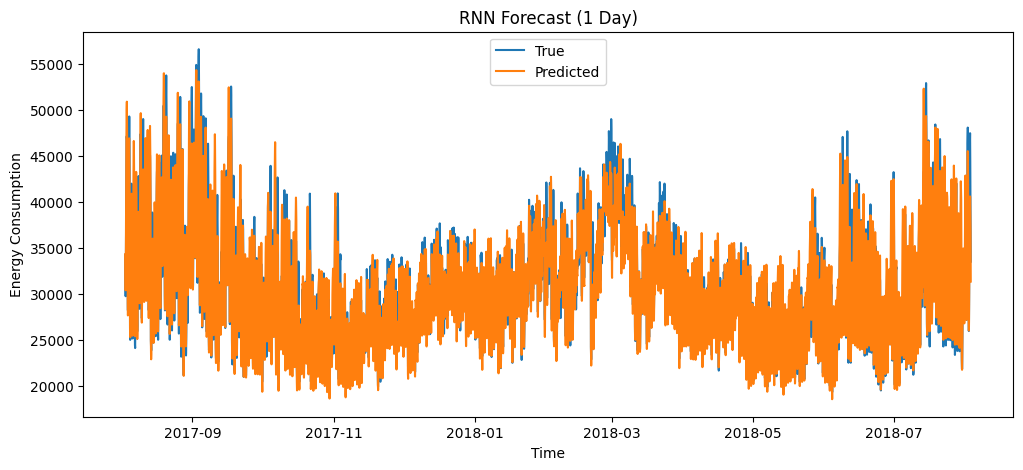

In [19]:
plot_forecast(y_true, y_pred_day, timesteps, "RNN Forecast (1 Day)")

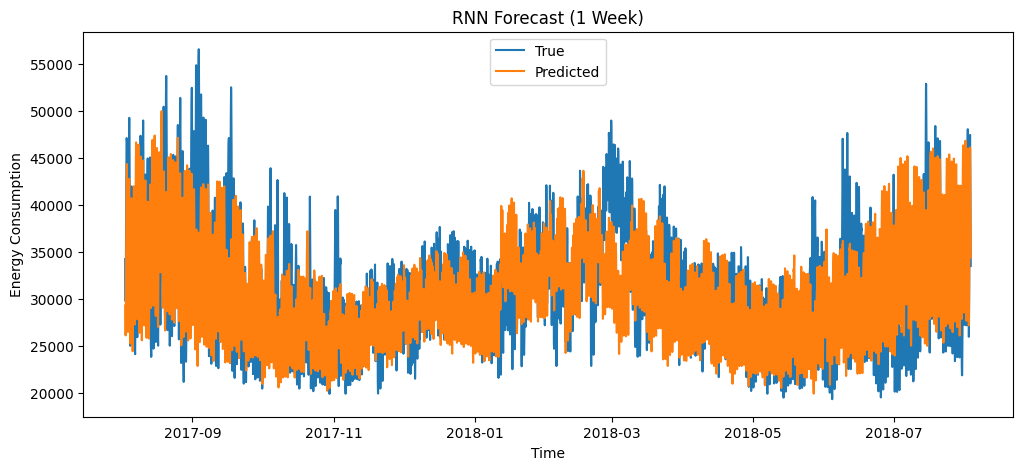

In [20]:
plot_forecast(y_true, y_pred_week, timesteps, "RNN Forecast (1 Week)")

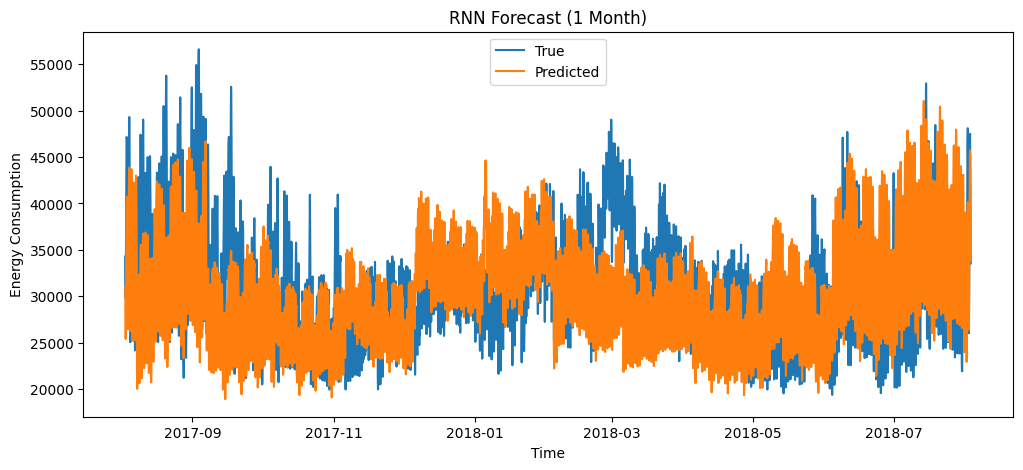

In [21]:
plot_forecast(y_true, y_pred_month, timesteps, "RNN Forecast (1 Month)")

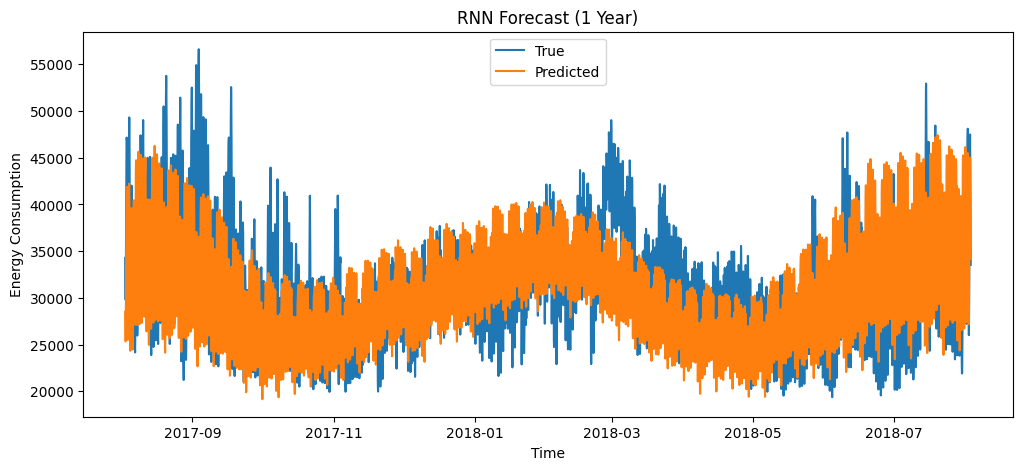

In [22]:
plot_forecast(y_true, y_pred_year, timesteps, "RNN Forecast (1 Year)")